# Notebook Evaluasi Algoritma

Notebook ini digunakan untuk mempermudah reporting simulasi, dan berisi:

1. **Authorization key count**
2. **NAKT least-count structural proofing**


## 1. Library Import dan Konfigurasi

In [1]:
import math
import random
from pathlib import Path
from datetime import timedelta

import pandas as pd
import matplotlib.pyplot as plt

import main as sim_config
from broker import Broker
from laporan import Laporan
from publisher import Publisher
from subscriber import format_date

In [2]:
# Letak data CSV yang akan digunakan untuk simulasi.
CSV_PATH = sim_config.CSV_PATH
# Nama publisher yang akan digunakan untuk simulasi, pengganti topic karena dalam simulasi ini hanya ada satu publisher.
PUBLISHER_NAME = sim_config.PUBLISHER_NAME
# Kunci master yang digunakan untuk semua simulasi.
MASTER_KEY = sim_config.MASTER_KEY
# Nilai default tingkat granularitas untuk simulasi.
LCNUM = sim_config.LCNUM

# Direktori output untuk menyimpan laporan hasil simulasi.
OUTPUT_DIR = Path("laporan")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Konfigurasi pembuktian granularitas.
# GRANULARITY_VALUES = [1024, 512, 256, 128, 64, 32, 16, 8, 4, 2, 1]
GRANULARITY_VALUES = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
SUBSCRIBER_COUNT = 500
RANDOM_SEED = 42

# Konfigurasi pembuktian algoritma NAKT.
NAKT_RANGE_SIZE_R = None


## 2. Pembuktian jumlah kuci yang dibagikan tiap rentang Granularitas

Bagian ini mengevaluasi berapa banyak unit kunci (key units) yang diperlukan ketika granulasi akses berubah. Pendekatan Standard (flat approach) menghitung kunci daun (leaf keys) satu per satu, sementara pohon hierarkis (hierarchical tree) menghitung node internal bersama (shared internal nodes) yang dikembalikan oleh metode `Publisher.get_key_metrics_for_range()`.

In [3]:
# Membuat reference publisher untuk mendapatkan domain datetime dari dataset yang sama.
broker_ref = Broker()
laporan_ref = Laporan()
publisher_ref = Publisher(
    name=PUBLISHER_NAME,
    broker=broker_ref,
    laporan=laporan_ref,
    csv_path=CSV_PATH,
    master_key=MASTER_KEY,
    lcnum=LCNUM,
)
publisher_ref.setup_datetime_tree()
domain_start, domain_end = publisher_ref.get_datetime_domain()

# Menggenerate rentang akses tetap agar setiap granularitas dievaluasi pada rentang langganan yang sama.
rng = random.Random(RANDOM_SEED)
total_days = (domain_end - domain_start).days
fixed_ranges = []

for _ in range(SUBSCRIBER_COUNT):
    a = rng.randint(0, total_days)
    b = rng.randint(0, total_days)
    range_start = domain_start + timedelta(days=min(a, b))
    range_end = domain_start + timedelta(days=max(a, b))
    fixed_ranges.append((range_start, range_end))

key_metrics_summary = []

for granularity_days in GRANULARITY_VALUES:
    broker = Broker()
    laporan = Laporan()
    publisher = Publisher(
        name=PUBLISHER_NAME,
        broker=broker,
        laporan=laporan,
        csv_path=CSV_PATH,
        master_key=MASTER_KEY,
        lcnum=granularity_days,
    )
    publisher.setup_datetime_tree()

    standard_key_counts = []
    tree_node_counts = []
    access_duration_days = []

    for range_start, range_end in fixed_ranges:
        metrics = publisher.get_key_metrics_for_range(range_start, range_end)
        standard_key_counts.append(metrics["standard_key_count"])
        tree_node_counts.append(metrics["tree_key_count"])
        access_duration_days.append(metrics["access_duration_days"])

    key_metrics_summary.append({
        "granularity_days_G": granularity_days,
        "standard_key_count": sum(standard_key_counts),
        "tree_key_count": sum(tree_node_counts),
        "max_standard_actual_leaf_keys": max(standard_key_counts),
        "max_tree_shared_nodes": max(tree_node_counts),
    })

shared_key_df = pd.DataFrame(key_metrics_summary)
shared_key_csv = OUTPUT_DIR / "granularity_validation_results.csv"
shared_key_df.to_csv(shared_key_csv, index=False)

print(f"Metrik kunci disimpan ke: {shared_key_csv}")
shared_key_df

Metrik kunci disimpan ke: laporan\granularity_validation_results.csv


,granularity_days_G,standard_key_count,tree_key_count,max_standard_actual_leaf_keys,max_tree_shared_nodes
0,1,679619,5005,3910,18
1,2,345940,5005,1989,18
2,4,173232,4794,995,18
3,8,86863,4431,498,16
4,16,43672,3987,250,15
5,32,22070,3497,126,13
6,64,11284,3015,64,12
7,128,5887,2525,32,10
8,256,3193,2049,16,8
9,512,1823,1571,8,6


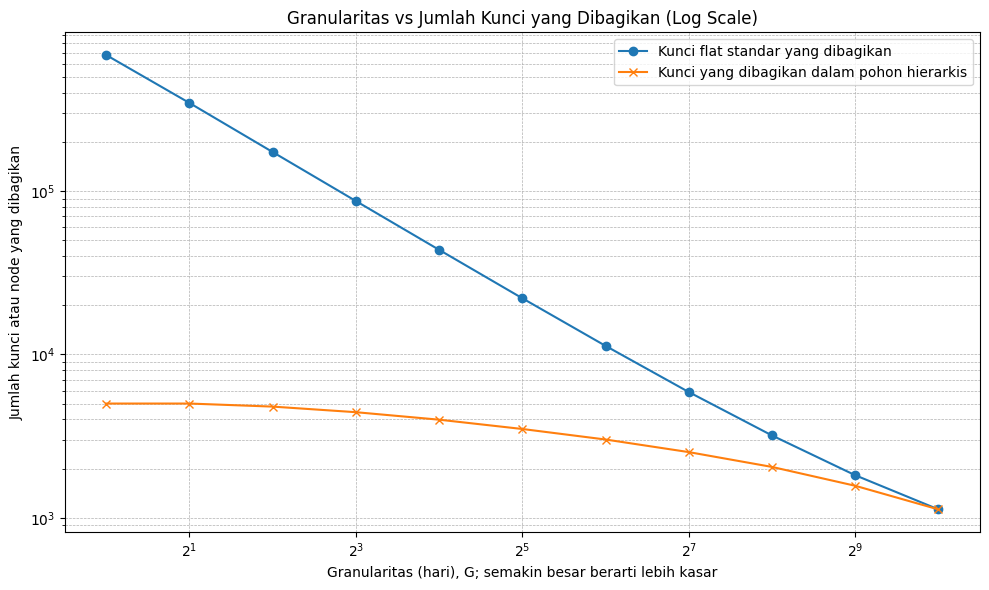

Grafik Granularitas vs Jumlah Kunci disimpan ke : laporan\granularity_vs_key_count.png


In [4]:
key_plot = OUTPUT_DIR / "granularity_vs_key_count.png"

plt.figure(figsize=(10, 6))
plt.plot(
    shared_key_df["granularity_days_G"],
    shared_key_df["standard_key_count"],
    marker="o",
    label="Kunci flat standar yang dibagikan",
)
plt.plot(
    shared_key_df["granularity_days_G"],
    shared_key_df["tree_key_count"],
    marker="x",
    label="Kunci yang dibagikan dalam pohon hierarkis",
)
plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Granularitas (hari), G; semakin besar berarti lebih kasar")
plt.ylabel("Jumlah kunci atau node yang dibagikan")
plt.title("Granularitas vs Jumlah Kunci yang Dibagikan (Log Scale)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(key_plot, dpi=200)
plt.show()

print(f"Grafik Granularitas vs Jumlah Kunci disimpan ke : {key_plot}")

## 3. Pembuktian algoritma NAKT

Bagian ini membuat grafik pembuktian untuk algoritma NAKT. Ukuran rentang `R` diambil dari domain tanggal-waktu (datetime domain) sebenarnya dari data CSV yang digunakan.

In [5]:
if "domain_start" not in globals() or "domain_end" not in globals():
    broker_ref = Broker()
    laporan_ref = Laporan()
    publisher_ref = Publisher(
        name=PUBLISHER_NAME,
        broker=broker_ref,
        laporan=laporan_ref,
        csv_path=CSV_PATH,
        master_key=MASTER_KEY,
        lcnum=LCNUM,
    )
    publisher_ref.setup_datetime_tree()
    domain_start, domain_end = publisher_ref.get_datetime_domain()

NAKT_RANGE_SIZE_R = (domain_end - domain_start).days + 1

least_count_results = []

for least_count in GRANULARITY_VALUES:
    if least_count < 1:
        continue
    if least_count > NAKT_RANGE_SIZE_R:
        continue

    normalized_leaf_blocks = NAKT_RANGE_SIZE_R / least_count

    if normalized_leaf_blocks <= 1:
        tree_height_or_max_keys = 0
        avg_keys_per_subscription = 1
    else:
        tree_height_or_max_keys = math.ceil(math.log2(normalized_leaf_blocks))
        avg_keys_per_subscription = 0.5 * math.log2(normalized_leaf_blocks)

    least_count_results.append({
        "range_size_R": NAKT_RANGE_SIZE_R,
        "least_count_lc": least_count,
        "normalized_leaf_blocks_R_over_lc": round(normalized_leaf_blocks, 3),
        "tree_height_or_max_keys": tree_height_or_max_keys,
        "avg_keys_per_subscription_est": round(avg_keys_per_subscription, 3),
    })

least_count_df = pd.DataFrame(least_count_results)
least_count_csv = OUTPUT_DIR / "nakt_least_count_metrics.csv"
least_count_df.to_csv(least_count_csv, index=False)

print(f"Jumlah rentang data R : {NAKT_RANGE_SIZE_R} days ({format_date(domain_start)} to {format_date(domain_end)})")
print(f"Metrik NAKT least-count disimpan ke: {least_count_csv}")
least_count_df


Jumlah rentang data R : 4026 days (2013-01-02 to 2024-01-10)
Metrik NAKT least-count disimpan ke: laporan\nakt_least_count_metrics.csv


,range_size_R,least_count_lc,normalized_leaf_blocks_R_over_lc,tree_height_or_max_keys,avg_keys_per_subscription_est
0,4026,1,4026.000,12,5.988
1,4026,2,2013.000,11,5.488
2,4026,4,1006.500,10,4.988
3,4026,8,503.250,9,4.488
4,4026,16,251.625,8,3.988
5,4026,32,125.812,7,3.488
6,4026,64,62.906,6,2.988
7,4026,128,31.453,5,2.488
8,4026,256,15.727,4,1.988
9,4026,512,7.863,3,1.488


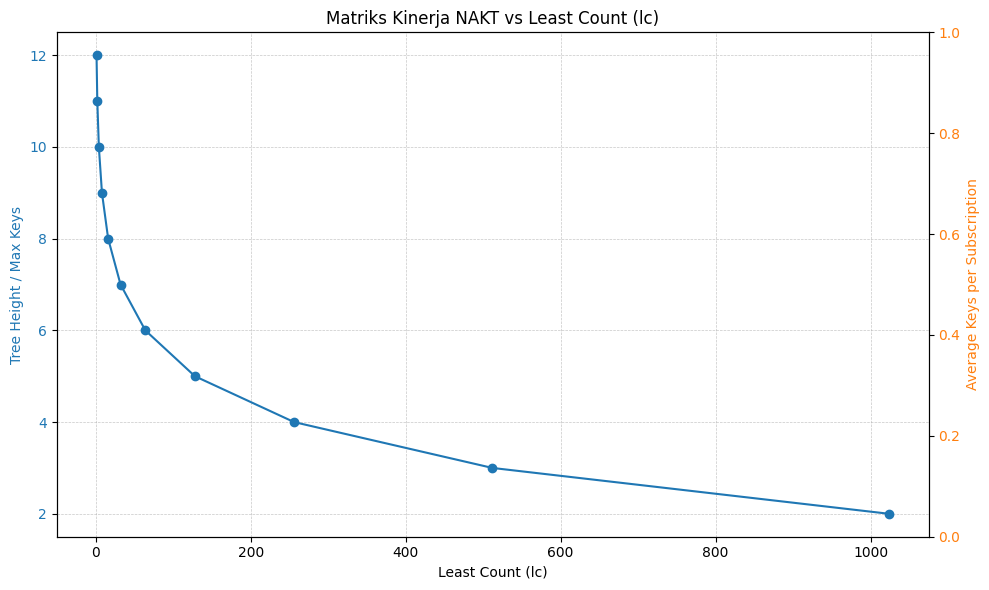

Grafik NAKT vs Least Count disimpan ke : laporan\nakt_performance_vs_least_count.png


In [6]:
least_count_plot = OUTPUT_DIR / "nakt_performance_vs_least_count.png"

fig, ax1 = plt.subplots(figsize=(10, 6))
left_color = "tab:blue"
right_color = "tab:orange"

ax1.plot(
    least_count_df["least_count_lc"],
    least_count_df["tree_height_or_max_keys"],
    marker="o",
    color=left_color,
)
ax1.set_xlabel("Least Count (lc)")
ax1.set_ylabel("Tree Height / Max Keys", color=left_color)
ax1.tick_params(axis="y", labelcolor=left_color)
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

ax2 = ax1.twinx()
ax2.set_ylabel("Average Keys per Subscription", color=right_color)
ax2.tick_params(axis="y", labelcolor=right_color)

plt.title(f"Matriks Kinerja NAKT vs Least Count (lc)")
fig.tight_layout()
plt.savefig(least_count_plot, dpi=200)
plt.show()

print(f"Grafik NAKT vs Least Count disimpan ke : {least_count_plot}")
